#### 1. 第一次作业的5只股票数据仿照案例2.8分析等权组合的表现

In [2]:
import pandas as pd

stock_data = pd.read_excel("D:/MyProjects/量化交易/Data/股票类/沪深300成分股收盘价日数据.xlsx",na_values=[0])
stock_data.head()

,代码,600519.SH,300750.SZ,601318.SH,600036.SH,000858.SZ,601012.SH,600900.SH,000333.SZ,002594.SZ,...,603087.SH,601236.SH,000800.SZ,002032.SZ,605499.SH,000877.SZ,300979.SZ,601825.SH,601698.SH,001289.SZ
0,股票,贵州茅台,宁德时代,中国平安,招商银行,五粮液,隆基绿能,长江电力,美的集团,比亚迪,...,甘李药业,红塔证券,一汽解放,苏泊尔,东鹏饮料,天山股份,华利集团,沪农商行,中国卫通,龙源电力
1,2010-01-04 00:00:00,103.531132,NaN,20.859549,10.466622,24.706569,NaN,5.434322,NaN,NaN,...,NaN,NaN,21.690557,8.652884,NaN,9.745129,NaN,NaN,NaN,NaN
2,2010-01-05 00:00:00,103.226522,NaN,21.122761,10.478442,24.965812,NaN,5.438442,NaN,NaN,...,NaN,NaN,20.875888,8.640344,NaN,10.513326,NaN,NaN,NaN,NaN
3,2010-01-06 00:00:00,101.593807,NaN,20.673753,10.259772,24.305922,NaN,5.405482,NaN,NaN,...,NaN,NaN,20.307318,8.82845,NaN,10.44748,NaN,NaN,NaN,NaN
4,2010-01-07 00:00:00,99.741774,NaN,20.290547,9.993822,23.567475,NaN,5.335441,NaN,NaN,...,NaN,NaN,19.46719,8.360275,NaN,10.008511,NaN,NaN,NaN,NaN


In [3]:
index_data = pd.read_excel("D:/MyProjects/量化交易/Data/市场指数类/沪深300指数日数据.xlsx",na_values=[0])
index_data = index_data[:-2]
index_data.tail()

,代码,名称,日期,开盘价(元),最高价(元),最低价(元),收盘价(元),成交额(百万),成交量(股)
5011,000300.SH,沪深300,2022-08-29,4063.88,4092.95,4059.60,4089.52,203086.12,9.435443e+09
5012,000300.SH,沪深300,2022-08-30,4088.53,4093.14,4048.52,4075.79,192649.00,9.330166e+09
5013,000300.SH,沪深300,2022-08-31,4057.14,4112.85,4046.62,4078.84,292974.67,1.324498e+10
5014,000300.SH,沪深300,2022-09-01,4066.19,4090.89,4041.13,4043.74,210898.50,9.738707e+09
5015,000300.SH,沪深300,2022-09-02,4054.84,4056.18,4004.91,4023.61,184468.33,8.678928e+09


In [4]:
# 清洗
# 股票
stock = stock_data.copy()
stock.iloc[0,0] = "日期"
stock.columns = stock.iloc[0]
stock = stock.drop(0)
stock = stock.set_index("日期")
stock_selected = stock[["工商银行","中国石油","万华化学","保利发展","贵州茅台"]]
stock_selected.tail(2)

,工商银行,中国石油,万华化学,保利发展,贵州茅台
日期,,,,,
2022-09-01 00:00:00,4.36,5.36,88.11,17.31,1880.89
2022-09-02 00:00:00,4.35,5.42,86.95,17.02,1875


In [5]:
# 指数
index = index_data.copy()
index.set_index("日期", inplace=True)
index = index[["收盘价(元)"]]
index.columns = ["沪深300指数"]
index.head(2)

,沪深300指数
日期,
2002-01-04,1316.46
2002-01-07,1302.08


In [6]:
# 合并 2010.1.4-2021.12.31
df = pd.merge(stock_selected, index, left_index=True, right_index=True)
df.index = pd.to_datetime(df.index)
df.dropna(inplace=True)
df = df[df.index < "2022-01-01"]
df.tail(2)

,工商银行,中国石油,万华化学,保利发展,贵州茅台,沪深300指数
日期,,,,,,
2021-12-30,4.359082,4.809091,97.571318,14.585126,2052.84969,4921.51
2021-12-31,4.349688,4.818905,97.842565,15.097055,2028.116561,4940.37


In [7]:
# 资金量
ret_accumulated = df/df.iloc[0]
vt = ret_accumulated*100000
vt["等权重策略"] = vt[["工商银行","中国石油","万华化学","保利发展","贵州茅台"]].mean(axis=1)
vt.tail(2)

,工商银行,中国石油,万华化学,保利发展,贵州茅台,沪深300指数,等权重策略
日期,,,,,,,
2021-12-30,160354.039533,49920.551386,924016.951737,303002.026444,1982833.222903,139213.290224,684025.358401
2021-12-31,160008.44893,50022.430063,926585.704185,313637.196909,1958943.666001,139746.777437,681839.489218


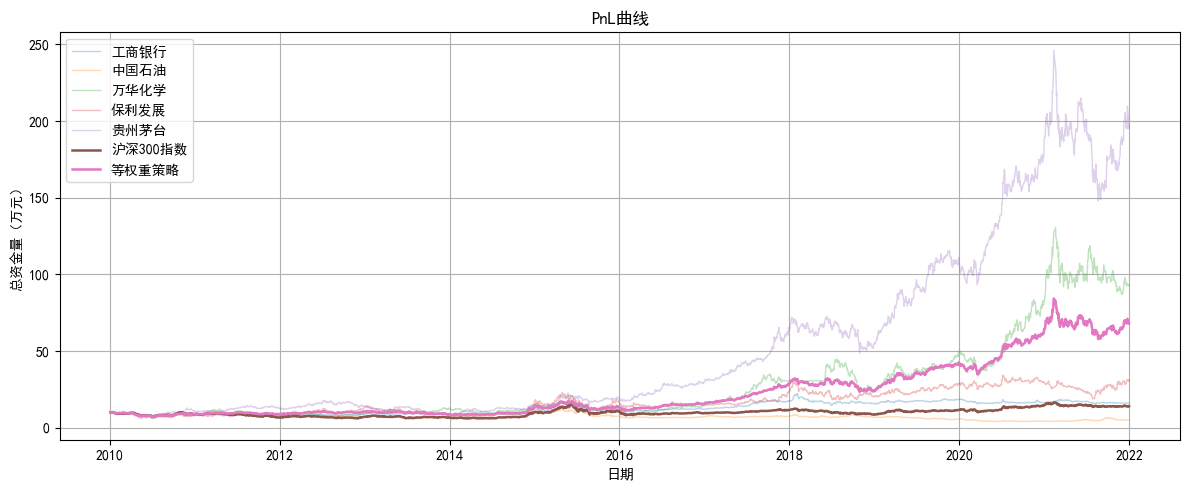

In [8]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# P&L曲线
vt_show = vt/10000

plt.figure(figsize=(12,5))
for col in vt_show.columns:
    if col in ["沪深300指数", "等权重策略"]:
        plt.plot(vt_show.index, vt_show[col], linewidth=1.8)
    else:
        plt.plot(vt_show.index, vt_show[col], linewidth=1, alpha=0.3)
plt.legend(vt_show.columns)
plt.title("PnL曲线")
plt.xlabel("日期")
plt.ylabel("总资金量（万元）")
plt.grid()
plt.tight_layout()
plt.savefig("D:/MyProjects/量化交易/Pictures/Hw2_PnL_equal_weight.png")
plt.show()

In [9]:
# 每年指标
ret = vt.pct_change().dropna()
avg_ret = (1+ret).resample("YE").prod()-1
avg_ret = avg_ret.apply(lambda x: round(x*100,2)).astype("str")+"%"
std_ret = ret.resample("YE").std()
std_ret = std_ret.apply(lambda x: round(x*100,2)).astype("str")+"%"
display(avg_ret, std_ret)

,工商银行,中国石油,万华化学,保利发展,贵州茅台,沪深300指数,等权重策略
日期,,,,,,,
2010-12-31,-16.14%,-15.35%,-17.43%,-24.17%,9.24%,-11.51%,-12.77%
2011-12-31,4.22%,-10.28%,-11.13%,3.98%,16.87%,-25.01%,1.62%
2012-12-31,2.77%,-3.95%,26.28%,65.62%,9.83%,7.55%,18.73%
2013-12-31,-8.17%,-11.67%,37.72%,-38.2%,-36.56%,-7.65%,-15.59%
2014-12-31,46.29%,46.3%,9.83%,104.74%,66.94%,51.66%,50.57%
2015-12-31,-1.53%,-21.58%,-17.18%,-0.04%,28.81%,5.58%,-0.53%
2016-12-31,1.37%,-4.27%,22.07%,-10.81%,56.45%,-11.28%,17.17%
2017-12-31,47.06%,3.19%,115.28%,59.92%,111.89%,21.78%,82.8%
2018-12-31,-10.9%,-9.24%,-23.19%,-14.19%,-14.21%,-25.31%,-15.46%


,工商银行,中国石油,万华化学,保利发展,贵州茅台,沪深300指数,等权重策略
日期,,,,,,,
2010-12-31,1.52%,1.52%,2.71%,2.89%,1.94%,1.59%,1.46%
2011-12-31,1.03%,0.99%,2.47%,2.43%,1.55%,1.3%,1.19%
2012-12-31,0.83%,0.8%,1.88%,2.36%,1.96%,1.29%,1.18%
2013-12-31,1.0%,0.95%,2.06%,2.44%,1.86%,1.4%,1.21%
2014-12-31,1.5%,1.5%,1.84%,2.57%,1.96%,1.21%,1.28%
2015-12-31,2.45%,3.07%,3.4%,3.94%,2.52%,2.48%,2.51%
2016-12-31,0.87%,1.24%,2.25%,2.32%,1.67%,1.4%,1.37%
2017-12-31,1.05%,0.86%,2.38%,1.77%,1.7%,0.64%,1.0%
2018-12-31,1.62%,1.64%,2.54%,2.86%,2.24%,1.35%,1.72%


In [10]:
# 无风险利率：用1年国债
import warnings
warnings.filterwarnings("ignore")

df_risk_free = pd.DataFrame()
for year in range(2010, 2022):
    df_year = pd.read_excel(
        f"D:/MyProjects/量化交易/Data/中国国债收益率_财政部/财政部-中国国债收益率曲线历史数据{year}年01月04日—{year}年12月31日.xlsx",
        na_values=[0]
    )
    df_risk_free = pd.concat([df_risk_free, df_year])
df_risk_free.set_index("日期", inplace=True)
df_risk_free.sort_index(inplace=True)
df_risk_free

,3月,6月,1年,2年,3年,5年,7年,10年,30年
日期,,,,,,,,,
2010-01-04,1.24,1.41,1.50,1.97,2.44,2.96,3.28,3.66,4.19
2010-01-05,1.26,1.41,1.51,1.98,2.46,2.99,3.28,3.66,4.19
2010-01-06,1.26,1.41,1.52,1.98,2.44,2.99,3.29,3.64,4.19
2010-01-07,1.28,1.41,1.55,2.00,2.45,3.00,3.32,3.65,4.19
2010-01-08,1.32,1.41,1.54,2.01,2.47,3.03,3.34,3.66,4.19
...,...,...,...,...,...,...,...,...,...
2021-12-27,2.32,2.36,2.35,2.47,2.54,2.67,2.83,2.81,3.35
2021-12-28,2.32,2.36,2.34,2.46,2.53,2.66,2.82,2.80,3.33
2021-12-29,2.28,2.33,2.34,2.42,2.51,2.63,2.80,2.79,3.32


In [11]:
rf_ann = (df_risk_free["1年"]/100).mean()
print(rf_ann)
rf_daily = (1+rf_ann)**(1/252)-1
print(rf_daily)

0.027415508021390374
0.00010733287631259358


In [12]:
ret

,工商银行,中国石油,万华化学,保利发展,贵州茅台,沪深300指数,等权重策略
日期,,,,,,,
2010-01-05,0.009346,0.019076,-0.019483,-0.03105,-0.002942,0.008149,-0.005011
2010-01-06,-0.011111,-0.013679,0.034989,-0.000943,-0.015817,-0.00626,-0.001514
2010-01-07,-0.024345,-0.006569,-0.033806,0.000472,-0.01823,-0.019841,-0.016637
2010-01-08,0.003839,-0.011756,-0.025486,0.013201,-0.010506,0.002498,-0.006208
2010-01-11,0.013384,0.020074,-0.007535,-0.022801,-0.004383,0.000552,-0.000177
...,...,...,...,...,...,...,...
2021-12-27,0.002151,0.002024,0.003951,-0.0205,-0.028381,-0.00041,-0.017412
2021-12-28,0.004292,-0.00404,0.002263,-0.005886,0.002983,0.007448,0.001969
2021-12-29,-0.004274,-0.004057,0.000098,-0.009868,-0.04545,-0.014625,-0.027663


In [13]:
# 整体指标
import pandas as pd
import numpy as np

# 年化收益率
ann_avg = (1+ret).prod()**(252/len(ret))-1
# 年化标准差
ann_std = ret.std()*np.sqrt(252)
# 夏普比率
sharpe_ratio = (ann_avg-rf_ann)/ann_std
# beta
beta = ret.cov()["沪深300指数"]/ret["沪深300指数"].var()
# 特雷诺比率
treynor_ratio = (ann_avg-rf_ann)/beta
# 詹森alpha
jensen_alpha = ann_avg-rf_ann-beta*(ann_avg["沪深300指数"]-rf_ann)
# 信息比率
excess_ret = ret.sub(rf_daily,axis=0)
beta_market = pd.DataFrame(
    np.outer(excess_ret["沪深300指数"],beta),
    index=ret.index,
    columns=ret.columns
)
epsilon = excess_ret-beta_market
info_ratio = jensen_alpha/(epsilon.std()*np.sqrt(252))
# 最大回撤
DD_t = vt.cummax()-vt
DD_t[DD_t<0] = 0
max_drawdown = DD_t.max()/10000

dic = {
    "平均年化收益率":ann_avg.round(4).apply(lambda x: round(x*100,2)).astype("str")+"%",
    "年化标准差":ann_std.round(4).apply(lambda x: round(x*100,2)).astype("str")+"%",
    "夏普比率": sharpe_ratio.round(4),
    "beta": beta.round(4),
    "特雷诺比率": treynor_ratio.round(4),
    "詹森alpha": jensen_alpha.round(4),
    "信息比率":info_ratio.round(4),
    "最大回撤/万元":max_drawdown.round(2)
}

res = pd.DataFrame(dic)
res

,平均年化收益率,年化标准差,夏普比率,beta,特雷诺比率,詹森alpha,信息比率,最大回撤/万元
工商银行,4.15%,20.82%,0.0674,0.5079,0.0277,0.0131,0.0754,7.63
中国石油,-5.81%,23.84%,-0.3587,0.5967,-0.1433,-0.0867,-0.4421,8.81
万华化学,21.22%,39.05%,0.4731,1.1064,0.167,0.1826,0.6117,43.39
保利发展,10.38%,40.69%,0.1878,1.1828,0.0646,0.0741,0.2429,15.34
贵州茅台,29.32%,31.43%,0.8457,0.7307,0.3637,0.2643,0.9912,98.3
沪深300指数,2.93%,22.75%,0.0085,1.0000,0.0019,0.0,0.0088,7.07
等权重策略,18.04%,24.3%,0.6298,0.8824,0.1734,0.1513,1.1054,26.4


#### 2. 尝试基于5只股票的资产池数据，按照如下两个逻辑分别生成策略：
- 策略1：基于认知规则的信号
- 策略2：基于模型的信号

分析和比较两种策略的绩效。数据分为三个子集：训练（建立认知或模型）50%、验证10%、测试40%。

策略1：认知规则
- 20日均线>60日均线
- 每只股票2万元，单独考虑

In [14]:
ret

,工商银行,中国石油,万华化学,保利发展,贵州茅台,沪深300指数,等权重策略
日期,,,,,,,
2010-01-05,0.009346,0.019076,-0.019483,-0.03105,-0.002942,0.008149,-0.005011
2010-01-06,-0.011111,-0.013679,0.034989,-0.000943,-0.015817,-0.00626,-0.001514
2010-01-07,-0.024345,-0.006569,-0.033806,0.000472,-0.01823,-0.019841,-0.016637
2010-01-08,0.003839,-0.011756,-0.025486,0.013201,-0.010506,0.002498,-0.006208
2010-01-11,0.013384,0.020074,-0.007535,-0.022801,-0.004383,0.000552,-0.000177
...,...,...,...,...,...,...,...
2021-12-27,0.002151,0.002024,0.003951,-0.0205,-0.028381,-0.00041,-0.017412
2021-12-28,0.004292,-0.00404,0.002263,-0.005886,0.002983,0.007448,0.001969
2021-12-29,-0.004274,-0.004057,0.000098,-0.009868,-0.04545,-0.014625,-0.027663


In [15]:
asset_ret = ret[["工商银行","中国石油","万华化学","保利发展","贵州茅台"]]

strategy1_df = pd.DataFrame(index=asset_ret.index)
df_signal = pd.DataFrame(index=asset_ret.index)

for stock in asset_ret.columns:
    r = asset_ret[stock]
    price = (1+r).cumprod()
    ma_short = price.rolling(20).mean()
    ma_long = price.rolling(60).mean()
    signal = (ma_short > ma_long).astype(int)
    signal = signal.shift(1).fillna(0)
    df_signal[stock] = signal
    strat_ret = r*signal
    final_ret = (1+strat_ret).cumprod()*20000
    strategy1_df[stock] = final_ret
portfolio_nav = strategy1_df.sum(axis=1)
portfolio_nav    

日期
2010-01-05         100000.0
2010-01-06         100000.0
2010-01-07         100000.0
2010-01-08         100000.0
2010-01-11         100000.0
                  ...      
2021-12-27    413328.954345
2021-12-28    413789.955059
2021-12-29      404526.9462
2021-12-30    407764.152144
2021-12-31    406208.431794
Length: 2916, dtype: object

策略2：机器学习预测T+1的收益率，持仓预测收益率最高的一只股票

In [16]:
asset_ret = ret[["工商银行","中国石油","万华化学","保利发展","贵州茅台"]].copy()
asset_ret = asset_ret.apply(pd.to_numeric, errors="coerce").dropna()

In [17]:
import numpy as np
import pandas as pd

def make_lstm_dataset(series, window=10):
    X, y, dates = [], [], []
    values = series.values.reshape(-1, 1)

    for i in range(window, len(values) - 1):
        X.append(values[i-window:i])
        y.append(values[i+1, 0])
        dates.append(series.index[i+1])

    X = np.array(X)
    y = np.array(y)
    return X, y, dates

In [18]:
def split_data(X, y, dates):
    n = len(X)
    train_end = int(n * 0.5)
    valid_end = int(n * 0.6)

    return {
        "X_train": X[:train_end],
        "y_train": y[:train_end],
        "X_valid": X[train_end:valid_end],
        "y_valid": y[train_end:valid_end],
        "X_test": X[valid_end:],
        "y_test": y[valid_end:],
        "dates_test": dates[valid_end:]
    }

In [19]:
from sklearn.preprocessing import StandardScaler

def scale_lstm_data(data):
    scaler = StandardScaler()

    X_train_shape = data["X_train"].shape
    X_valid_shape = data["X_valid"].shape
    X_test_shape = data["X_test"].shape

    X_train_2d = data["X_train"].reshape(-1, 1)
    X_valid_2d = data["X_valid"].reshape(-1, 1)
    X_test_2d = data["X_test"].reshape(-1, 1)

    X_train_scaled = scaler.fit_transform(X_train_2d).reshape(X_train_shape)
    X_valid_scaled = scaler.transform(X_valid_2d).reshape(X_valid_shape)
    X_test_scaled = scaler.transform(X_test_2d).reshape(X_test_shape)

    return X_train_scaled, X_valid_scaled, X_test_scaled, scaler

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error

In [21]:
def build_lstm_model(window):
    model = Sequential([
        LSTM(32, input_shape=(window, 1)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

In [22]:
def train_one_stock_lstm(series, window=10, epochs=50, batch_size=32):
    X, y, dates = make_lstm_dataset(series, window=window)
    data = split_data(X, y, dates)

    X_train, X_valid, X_test, scaler = scale_lstm_data(data)

    model = build_lstm_model(window)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train, data["y_train"],
        validation_data=(X_valid, data["y_valid"]),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stop]
    )

    pred_valid = model.predict(X_valid, verbose=0).flatten()
    pred_test = model.predict(X_test, verbose=0).flatten()

    val_mse = mean_squared_error(data["y_valid"], pred_valid)
    pred_test = pd.Series(pred_test, index=data["dates_test"])

    return {
        "model": model,
        "val_mse": val_mse,
        "pred_test": pred_test
    }

In [23]:
results = {}
pred_df = pd.DataFrame()

stocks = ["工商银行","中国石油","万华化学","保利发展","贵州茅台"]

for stock in stocks:
    res = train_one_stock_lstm(asset_ret[stock], window=10, epochs=50, batch_size=32)
    results[stock] = res
    pred_df[stock] = res["pred_test"]

pred_df.head()

,工商银行,中国石油,万华化学,保利发展,贵州茅台
2017-03-28,0.000845,-0.001558,0.001690,0.001704,0.001636
2017-03-29,0.000845,-0.001227,0.001690,0.001875,0.004381
2017-03-30,0.000845,0.001163,0.001690,0.002565,0.002002
2017-03-31,0.000845,-0.001310,0.001444,0.002905,0.001636
2017-04-05,0.000845,-0.002191,0.001658,0.002431,0.001636


In [25]:
signal_model = pred_df.idxmax(axis=1)
position_model = signal_model.shift(1).dropna()

strategy_ret = pd.Series(
    [asset_ret.loc[date, stock] for date, stock in zip(position_model.index, position_model)],
    index=position_model.index
)

portfolio2_nav = (1 + strategy_ret).cumprod() * 100000

In [26]:
portfolio2_nav

2017-03-29     99164.054336
2017-03-30     99807.657869
2017-03-31    100228.343466
2017-04-05    101385.228858
2017-04-06    101805.914454
                  ...      
2021-12-27    206335.713404
2021-12-28    205502.033754
2021-12-29    196161.993327
2021-12-30    196813.694301
2021-12-31    203721.724631
Length: 1161, dtype: float64

In [70]:
# ret["策略1"] = strategy1_df["策略1"]
ret["策略2"] = strategy2_df["策略2"]
ret.dropna(inplace=True)
zero = pd.DataFrame(0, index=[pd.to_datetime("2017-03-22")], columns=ret.columns)
ret = pd.concat([zero, ret])
vt = (1+ret).cumprod()*100000
vt["策略1"] = portfolio_nav
ret["策略1"] = portfolio_nav.pct_change().fillna(0)
vt

,工商银行,中国石油,万华化学,保利发展,贵州茅台,沪深300指数,等权重策略,策略1,策略2
2017-03-22,100000,100000,100000,100000,100000,100000,100000,100000.0,100000.000000
2017-03-23,100214.592275,99248.120301,99471.099358,100941.422594,98811.093085,100345.79209,99553.352267,100000.0,100941.422594
2017-03-24,100643.776824,99749.373434,104042.312051,101255.230126,98058.203204,101146.360198,100313.529654,100000.0,101451.227759
2017-03-27,101931.330472,99248.120301,102568.945977,101046.025105,96030.216995,100811.29259,99316.766155,100000.0,100941.422594
2017-03-28,101931.330472,98370.927318,102682.281828,100104.60251,96395.254512,100572.745323,99249.934685,100000.0,100049.263556
...,...,...,...,...,...,...,...,...,...
2021-12-27,126552.339768,70988.03189,535271.413263,198900.00715,576577.432138,142586.91903,396321.48943,230998.236098,227629.215299
2021-12-28,127095.482857,70701.211559,536482.553697,197729.241902,578297.573833,143648.932624,397101.981915,231044.7511,228308.316634
2021-12-29,126552.339768,70414.391228,536535.211977,195777.966488,552014.025103,141548.093506,386117.06813,227523.898768,217931.733648
2021-12-30,126009.196679,70270.981062,530374.19325,196428.391626,561209.751146,142650.396371,388613.000525,228751.156896,221562.149593


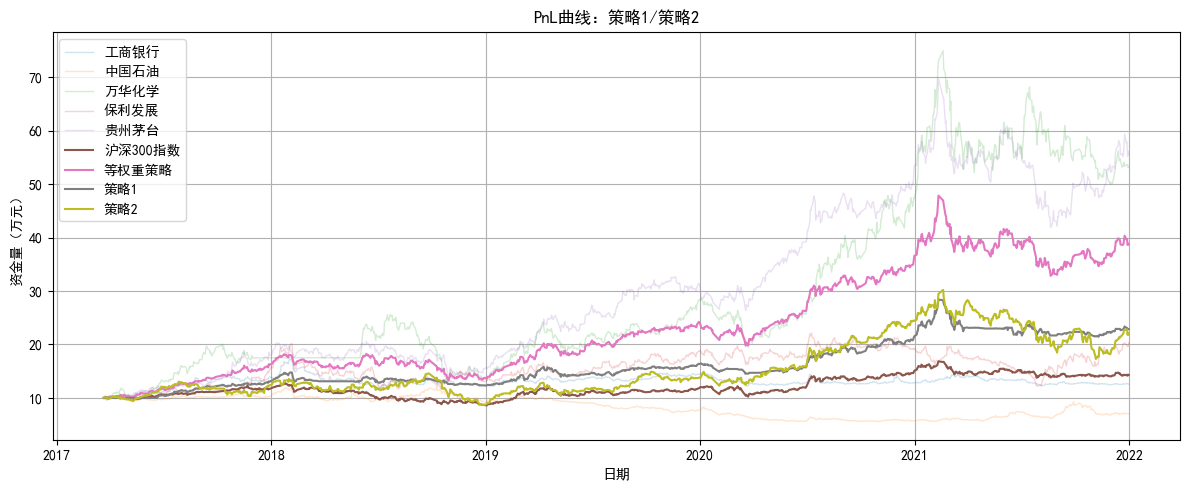

In [68]:
# P&L曲线：策略1，策略2
vt_show = vt/10000
plt.figure(figsize=(12,5))
for col in vt_show.columns:
    if col in ["沪深300指数", "等权重策略", "策略1", "策略2"]:
        plt.plot(vt_show.index, vt_show[col], linewidth=1.5)
    else:
        plt.plot(vt_show.index, vt_show[col], linewidth=1, alpha=0.2)
plt.legend(vt_show.columns)
plt.title("PnL曲线：策略1/策略2")
plt.xlabel("日期")
plt.ylabel("资金量（万元）")
plt.grid()
plt.tight_layout()
plt.savefig("D:/MyProjects/量化交易/Pictures/Hw2_PnL_1_2.png")
plt.show()

In [71]:
# 每年指标
ret_selected = ret[["沪深300指数","等权重策略","策略1","策略2"]]
avg_ret = (1+ret_selected).resample("YE").prod()-1
avg_ret = avg_ret.apply(lambda x: round(x*100,2)).astype("str")+"%"
std_ret = ret_selected.resample("YE").std()
std_ret = std_ret.apply(lambda x: round(x*100,2)).astype("str")+"%"
display(avg_ret, std_ret)

,沪深300指数,等权重策略,策略1,策略2
2017-12-31,16.83%,61.91%,30.8%,23.5%
2018-12-31,-25.31%,-15.46%,-5.63%,-29.81%
2019-12-31,36.07%,76.72%,32.62%,59.31%
2020-12-31,27.21%,51.22%,31.57%,76.68%
2021-12-31,-5.2%,5.9%,6.26%,-10.3%


,沪深300指数,等权重策略,策略1,策略2
2017-12-31,0.67%,1.05%,0.66%,1.61%
2018-12-31,1.35%,1.72%,0.95%,2.23%
2019-12-31,1.25%,1.49%,1.17%,1.7%
2020-12-31,1.43%,1.56%,1.18%,1.98%
2021-12-31,1.17%,1.81%,1.3%,2.42%


In [72]:
# 整体指标
import pandas as pd
import numpy as np

# 年化收益率
ann_avg = (1+ret_selected).prod()**(252/len(ret_selected))-1
# 年化标准差
ann_std = ret_selected.std()*np.sqrt(252)
# 夏普比率
sharpe_ratio = (ann_avg-rf_ann)/ann_std
# beta
beta = ret_selected.cov()["沪深300指数"]/ret_selected["沪深300指数"].var()
# 特雷诺比率
treynor_ratio = (ann_avg-rf_ann)/beta
# 詹森alpha
jensen_alpha = ann_avg-rf_ann-beta*(ann_avg["沪深300指数"]-rf_ann)
# 信息比率
excess_ret = ret_selected.sub(rf_daily,axis=0)
beta_market = pd.DataFrame(
    np.outer(excess_ret["沪深300指数"],beta),
    index=ret_selected.index,
    columns=ret_selected.columns
)
epsilon = excess_ret-beta_market
info_ratio = jensen_alpha/(epsilon.std()*np.sqrt(252))
# 最大回撤
vt_selected = vt[["沪深300指数","等权重策略","策略1","策略2"]]
DD_t = vt_selected.cummax()-vt_selected
DD_t[DD_t<0] = 0
max_drawdown = DD_t.max()/10000

dic = {
    "平均年化收益率":ann_avg.round(4).apply(lambda x: round(x*100,2)).astype("str")+"%",
    "年化标准差":ann_std.round(4).apply(lambda x: round(x*100,2)).astype("str")+"%",
    "夏普比率": sharpe_ratio.round(4),
    "beta": beta.round(4),
    "特雷诺比率": treynor_ratio.round(4),
    "詹森alpha": jensen_alpha.round(4),
    "信息比率":info_ratio.round(4),
    "最大回撤/万元":max_drawdown.round(2)
}

res = pd.DataFrame(dic)
res

,平均年化收益率,年化标准差,夏普比率,beta,特雷诺比率,詹森alpha,信息比率,最大回撤/万元
沪深300指数,8.07%,19.44%,0.2741,1.0000,0.0533,0.0,0.328,4.13
等权重策略,34.0%,24.87%,1.257,1.0187,0.3068,0.2583,1.717,15.0
策略1,19.6%,17.31%,0.9739,0.6117,0.2756,0.136,1.081,6.94
策略2,18.45%,32.19%,0.4879,0.9064,0.1733,0.1088,0.4038,12.93
